In [130]:
#importing the necessary libraries for data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [131]:
#importing the necessary libraries for data manipulation and visualization
import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

In [132]:
df = pd.read_csv("AIML Dataset.csv")
#it will read the dataset and store it in a dataframe called df

In [133]:
df.head()
#it will show the first 5 rows of the dataset

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [134]:
df.info()
#it will show the information about the dataset such as the number of rows, columns, data types, and memory usage

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


In [135]:
df.columns
#it will show the column names of the dataset

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='str')

In [136]:
df["isFraud"].value_counts()
#it will show the count of each class in the target variable "isFraud"

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [137]:
df["isFlaggedFraud"].value_counts()
#it will show the count of each class in the target variable "isFlaggedFraud"

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [138]:
df.isnull().sum().sum()
#

np.int64(0)

In [139]:
df.shape
#it will show the number of rows and columns in the dataset

(6362620, 11)

In [140]:
round((df["isFraud"].value_counts()[1] / df.shape[0]) * 100,2)
#it will show the percentage of fraudulent transactions in the dataset

np.float64(0.13)

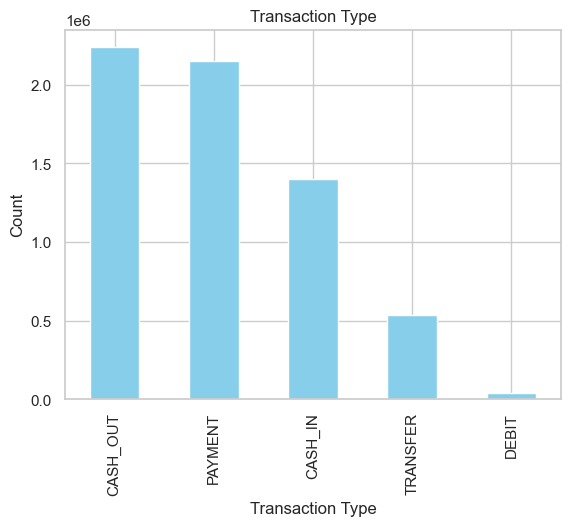

In [141]:
df["type"].value_counts().plot(kind="bar", title="Transaction Type", color = "skyblue")
#it will show the count of each class in the "type" column as a bar plot
plt.xlabel("Transaction Type") #it will set the label for the x-axis as "Transaction Type"
plt.ylabel("Count") #it will set the label for the y-axis as "Count"
plt.show() #it will display the plot

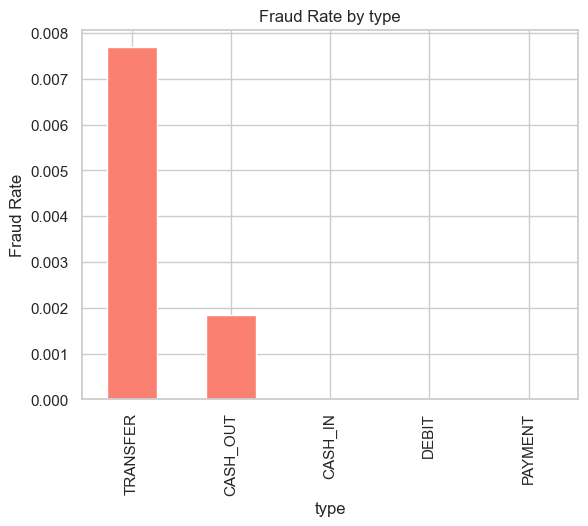

In [142]:
fraud_by_type = df.groupby("type")["isFraud"].mean().sort_values(ascending = False)
fraud_by_type.plot(kind="bar", title="Fraud Rate by type", color = "salmon")
#it will show the average fraud rate for each transaction type as a bar plot
plt.ylabel("Fraud Rate") #it will set the label for the y-axis as "Fraud Rate"
plt.show() #it will display the plot

In [143]:
df["amount"].describe().astype(int)
#it will show the statistical summary of the "amount" column such as count, mean,std, min, 25%, 50%, 75%, and max values

count     6362620
mean       179861
std        603858
min             0
25%         13389
50%         74871
75%        208721
max      92445516
Name: amount, dtype: int64

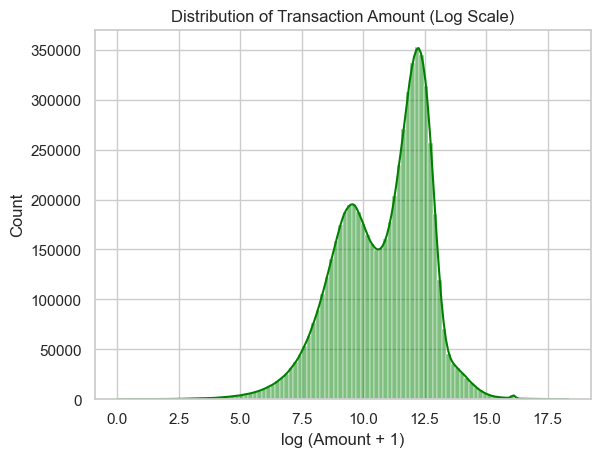

In [144]:
sns.histplot(np.log1p(df["amount"]), bins= 100, kde=True, color = "green")
#it will show the distribution of the "amount" column on a log scale using a histogram with a kernel density estimate (KDE) overlay
plt.title("Distribution of Transaction Amount (Log Scale)")
#it will set the title of the plot as "Distribution of Transaction Amount (Log Scale)"
plt.xlabel("log (Amount + 1)")
#it will set the label for the x-axis as "log (Amount + 1)"
plt.show()
#it will display the plot

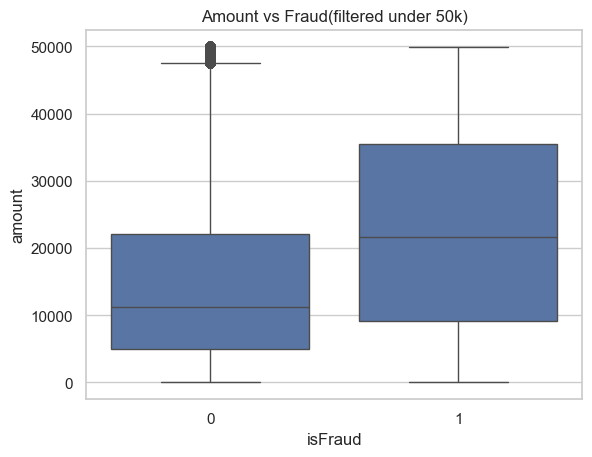

In [ ]:
sns.boxplot(data = df[df["amount"] < 50000], x = "isFraud", y = "amount")
#it will show the distribution of the "amount" column for fraudulent and non-fraudulent transactions using a box plot, excluding transactions 
# with an amount greater than 50000 to focus on the majority of the data
plt.title("Amount vs Fraud(filtered under 50k)")
#it will set the title of the plot as "Amount vs Fraud(filtered under 50k)"
plt.show()

In [146]:
df.columns
#it will show the column names of the dataset

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='str')

In [ ]:
df["balanceDiffOrig"] = df["oldbalanceOrg"] - df["newbalanceOrig"]
#it will create a new column called "balanceDiffOrig" which is the difference between the old balance and the new balance of the origin account
df["blanceDiffDest"] = df["oldbalanceDest"] - df["newbalanceDest"]
#it will create a new column called "balanceDiffDest" which is the difference between the old balance and the new balance of the destination account

In [148]:
(df["balanceDiffOrig"] < 0).sum()
#it will show a boolean series indicating whether the "balanceDiffOrig" is negative, which

np.int64(1399253)

In [ ]:
(df["blanceDiffDest"] < 0).sum()
#it will show a boolean series indicating whether the "balanceDiffDest" is negative, which can indicate potential fraudulent activity if the 
# destination account's balance decreases after the transaction.

np.int64(2806464)

In [150]:
df.head(2)
#it will show the first 2 rows of the dataset, including the newly created columns "balanceDiffOrig" and "blanceDiffDest"

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,blanceDiffDest
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0


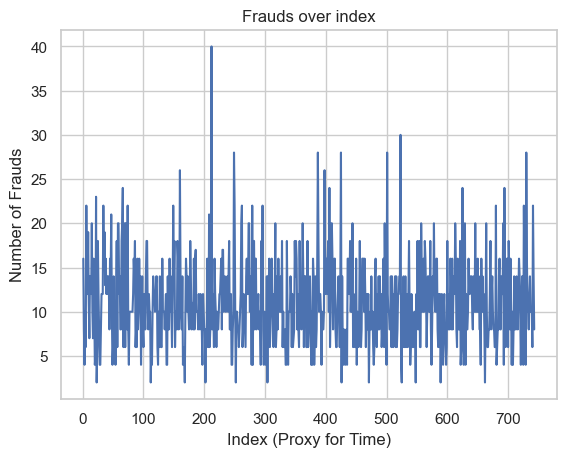

In [ ]:
frauds_per_step = df[df["isFraud"] == 1]["step"].value_counts().sort_index()
#it will filter the dataset to include only fraudulent transactions, then count the number of fraudulent transactions for each unique value in the
#  "step" column, and finally sort the counts by the index (which represents the time steps)
plt.plot(frauds_per_step.index, frauds_per_step.values, label="Frauds per Index")
#it will create a line plot with the index (time steps) on the x-axis and the number of fraudulent transactions on the y-axis, and label the line 
# as "Frauds per Index"
plt.xlabel("Index (Proxy for Time)")
plt.ylabel("Number of Frauds")
plt.title("Frauds over index")
plt.grid(True)
plt.show()

In [152]:
df.drop(columns="step",inplace=True)
#it will drop the "step" column from the dataset, which is a proxy for time and may not be relevant for the analysis or modeling of fraud detection.

In [153]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,blanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


In [154]:
top_senders = df["nameOrig"].value_counts().head(10)
#it will count the occurrences of each unique value in the "nameOrig" column, which represents the origin account names, and then select the top 10 most frequent origin account names to identify the most active senders in the dataset.

In [155]:
top_senders
#it will display the top 10 most active senders in the dataset based on the count of transactions initiated by each sender.

nameOrig
C2098525306    3
C400299098     3
C1999539787    3
C1065307291    3
C545315117     3
C1976208114    3
C1784010646    3
C1530544995    3
C1902386530    3
C1677795071    3
Name: count, dtype: int64

In [156]:
top_receivers = df["nameDest"].value_counts().head(10)
#it will count the occurrences of each unique value in the "nameDest" column, which represents the destination account names, and then select the top 10 most frequent destination account names to identify the most active receivers in the dataset.

In [157]:
top_receivers
#it will display the top 10 most active receivers in the dataset based on the count of transactions received by each receiver.

nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
C1590550415    101
C451111351      99
C1789550256     99
C1360767589     98
C1023714065     97
Name: count, dtype: int64

In [158]:
fraud_users = df[df["isFraud"] == 1]["nameOrig"].value_counts().head(10)
#it will filter the dataset to include only fraudulent transactions, then count the occurrences of each unique value in the "nameOrig" column for those fraudulent transactions, and finally select the top 10 most frequent origin account names among the fraudulent transactions to identify the most common fraudsters in the dataset.

In [159]:
fraud_users
#it will display the top 10 most common fraudsters in the dataset based on the count of fraudulent transactions initiated by each sender.

nameOrig
C1305486145    1
C840083671     1
C1420196421    1
C2101527076    1
C137533655     1
C1118430673    1
C749981943     1
C1334405552    1
C467632528     1
C1364127192    1
Name: count, dtype: int64

In [160]:
fraud_types = df[df["type"].isin(["TRANSFER", "CASH_OUT"])]
#it will filter the dataset to include only transactions of type "TRANSFER" and "CASH_OUT", which are more likely to be associated with fraudulent activity, and store the filtered dataset in a new dataframe called "fraud_types".

In [161]:
fraud_types["type"].value_counts()
#it will show the count of each class in the "type" column for the filtered dataset "fraud_types", which includes only "TRANSFER" and "CASH_OUT" transactions.

type
CASH_OUT    2237500
TRANSFER     532909
Name: count, dtype: int64

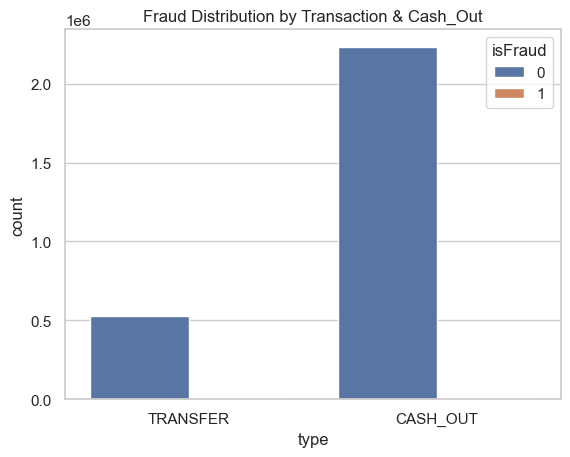

In [ ]:
sns.countplot(data=fraud_types, x="type", hue="isFraud")
#it will show the count of each class in the "type" column for the filtered dataset "fraud_types", which includes only "TRANSFER" and "CASH_OUT" 
# transactions, with a hue based on the "isFraud" column to differentiate between fraudulent and non-fraudulent transactions.
plt.title("Fraud Distribution by Transaction & Cash_Out")
#it will set the title of the plot as "Fraud Distribution by Transaction & Cash_Out"
plt.show()

In [163]:
corr = df[["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest", "isFraud"]].corr()
#it will calculate the correlation matrix for the specified columns, which includes the transaction amount, old and new balances of the origin and destination accounts, and the target variable "isFraud". The correlation matrix will show the pairwise correlation coefficients between these variables, which can help identify potential relationships and patterns in the data related to fraudulent transactions.

In [164]:
corr
#it will display the correlation matrix calculated in the previous step, showing the correlation coefficients between the specified variables.

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
amount,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.076688
oldbalanceOrg,-0.002762,1.000000,0.998803,0.066243,0.042029,0.010154
newbalanceOrig,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.008148
oldbalanceDest,0.294137,0.066243,0.067812,1.000000,0.976569,-0.005885
newbalanceDest,0.459304,0.042029,0.041837,0.976569,1.000000,0.000535
isFraud,0.076688,0.010154,-0.008148,-0.005885,0.000535,1.000000


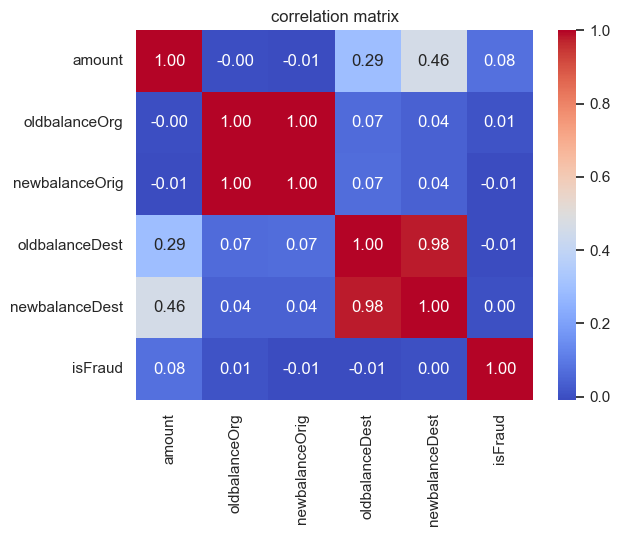

In [ ]:
sns.heatmap(corr,annot=True,cmap="coolwarm", fmt=".2f")
#it will create a heatmap to visualize the correlation matrix, with annotations showing the correlation coefficients formatted to two decimal 
# places, and using the "coolwarm" colormap to differentiate between positive and negative correlations.
plt.title("correlation matrix")
#it will set the title of the plot as "correlation matrix"
plt.show()

In [166]:
zero_after_transfer = df[
    (df["oldbalanceOrg"]> 0) & 
    (df["newbalanceOrig"] == 0) &
    (df["type"].isin(["TRANSFER","CASH_OUT"]))
]

In [167]:
len(zero_after_transfer)
#it will filter the dataset to include only transactions where the old balance of the origin account is

1188074

In [168]:
zero_after_transfer.head()
#it will show the first 5 rows of the filtered dataset "zero_after_transfer", which includes transactions where the old balance of the origin account is greater than 0, the new balance of the origin account is 0, and the transaction type is either "TRANSFER" or "CASH_OUT". This can help identify potential fraudulent transactions where the entire balance is transferred out or cashed out.

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,blanceDiffDest
2,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,0,181.0,0.00
3,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,0,181.0,21182.00
15,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,0,15325.0,-46430.44
19,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0,0,705.0,22425.00
24,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0,0,10835.0,-2712905.89


In [169]:
df["isFraud"].value_counts()
#it will show the count of each class in the target variable "isFraud"

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [170]:
from sklearn.model_selection import train_test_split
#for splitting the dataset into training and testing sets
from sklearn.preprocessing import StandardScaler
#for standardizing the features by removing the mean and scaling to unit variance
from sklearn.linear_model import LogisticRegression
# for building a logistic regression model for binary classification
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
# for evaluating the performance of the classification model using various metrics such as classification report, confusion matrix, ROC AUC score, and ROC curve
from sklearn.pipeline import Pipeline
# for creating a machine learning pipeline to streamline the process of data preprocessing and model training
from sklearn.compose import ColumnTransformer
# for applying different preprocessing steps to different subsets of features in the dataset
from sklearn.preprocessing import OneHotEncoder
# for encoding categorical features using one-hot encoding to convert them into a format suitable for machine learning algorithms

In [171]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,blanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


In [172]:
df_model = df.drop(["nameOrig", "nameDest", "isFlaggedFraud"], axis = 1)
#it will drop the columns "nameOrig", "nameDest", and "is FlaggedFraud" from the dataset, which are not relevant for the analysis or modeling of fraud detection, and store the resulting dataframe in a new variable called "df_model". This will help focus on the relevant features for building a fraud detection model.

In [173]:
df_model.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balanceDiffOrig,blanceDiffDest
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,9839.64,0.0
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,1864.28,0.0
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,181.00,0.0
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,181.00,21182.0
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,11668.14,0.0


In [174]:
categorical = ["type"]
#it will define a list called "categorical" which contains the name of the categorical feature "type" in the dataset. This will help in applying appropriate preprocessing steps to the categorical feature when building the machine learning model.
numeric = ["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest", "balanceDiffOrig", "blanceDiffDest"]
#it will define two lists, "categorical" and "numeric", which contain the names of the categorical and numerical features in the dataset, respectively. This will help in applying appropriate preprocessing steps to each type of feature when building the machine learning model.

In [ ]:
y = df_model["isFraud"]
#it will define the target variable "y" as the "isFraud" column from the "df_model" dataframe, which indicates whether a transaction 
# is fraudulent or not. This variable will be used as the dependent variable in the machine learning model.
x = df_model.drop("isFraud", axis = 1)
#it will define the feature variables "x" by dropping the "isFraud" column from the "df_model" dataframe. This will create a new dataframe 
# containing only the independent variables that will be used to predict the target variable "y" in the machine learning model.

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, stratify = y)
#it will split the dataset into training and testing sets, with 70% of the data used for training and 30% for testing. The "stratify = y" parameter ensures that the class distribution 
#of the target variable "y" is maintained in both the training and testing sets, which is important for imbalanced datasets like this one.

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric),
        ("cat", OneHotEncoder(drop = "first"), categorical)
    ],
    remainder = "drop"
)
#it will create a ColumnTransformer called "preprocessor" that applies different preprocessing steps to the numerical and categorical features 
# in the dataset. The numerical features will be standardized using StandardScaler, while the categorical feature "type" will be encoded using 
# OneHotEncoder with the first category dropped to avoid multicollinearity. The "remainder = 'drop'" parameter ensures that any columns not 
# specified in the transformers will be dropped from the dataset.

In [ ]:
pipeline = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(class_weight = "balanced", max_iter = 1000))
])
#it will create a machine learning pipeline called "pipeline" that consists of two steps:
#1. "prep": This step applies the "preprocessor" ColumnTransformer to the data, which standardizes the numerical features and encodes the categorical feature.
#2. "clf": This step applies a Logistic Regression classifier to the preprocessed data, with the "class_weight" parameter set to "balanced" to handle class imbalance in the 
# target variable, and "max_iter" set to 1000 to allow for sufficient iterations for convergence during model training. This pipeline will streamline the process of data 
# preprocessing and model training for fraud detection.  

In [ ]:
pipeline.fit(x_train, y_train)
#it will fit the machine learning pipeline to the training data, which involves applying the preprocessing steps defined in the "preprocessor" 
# ColumnTransformer to the training features and then training the Logistic Regression classifier on the preprocessed training data. This step
#  will prepare the model for making predictions on the test set and evaluating its performance.

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

In [180]:
y_pred = pipeline.predict(x_test)

In [ ]:
print(classification_report(y_test,y_pred))
#it will generate a classification report that includes precision, recall, f1-score, and support for each class in the target variable 
# "isFraud" based on the true labels "y_test" and the predicted labels "y_pred". This report will help evaluate the performance of the logistic 
# regression model in detecting fraudulent transactions.

              precision    recall  f1-score   support

           0       1.00      0.95      0.97   1906322
           1       0.02      0.94      0.04      2464

    accuracy                           0.95   1908786
   macro avg       0.51      0.95      0.51   1908786
weighted avg       1.00      0.95      0.97   1908786



In [ ]:
confusion_matrix(y_test, y_pred)
#it will generate a confusion matrix based on the true labels "y_test" and the predicted labels "y_pred". The confusion matrix will show the number
#  of true positives, true negatives, false positives, and false negatives, which can help evaluate the performance of the logistic regression model
#  in detecting fraudulent transactions.

array([[1805545,  100777],
       [    140,    2324]])

In [ ]:
pipeline.score(x_test, y_test) * 100
#it will calculate the accuracy of the logistic regression model on the test set by comparing the true labels "y_test" with the predicted labels 
# "y_pred", and then multiply by 100 to express it as a percentage. This will provide an overall measure of how well the model is performing in 
# classifying fraudulent transactions.

94.71302702345888

In [184]:
import joblib
#for saving the trained machine learning model to a file using joblib, which allows for easy serialization and deserialization 
# of Python objects, including machine learning models.

joblib.dump(pipeline, "fraud_detection_model.pkl")
#it will save the trained machine learning pipeline to a file named "fraud_detection_model.pkl" using joblib, which allows for later loading and 
# use of the model for making predictions on new data without needing to retrain it.

['fraud_detection_model.pkl']